# Energy Consumption Forecasting Using Machine Learning

### Project Objective

The objective of this project is to analyze historical energy consumption
and build a machine learning model to forecast future energy consumption.

The project focuses on understanding consumption patterns, creating
time-based features, training forecasting models, and evaluating their
prediction performance.

In [199]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings('ignore')

print("All Modules Loaded Successfully!!")

All Modules Loaded Successfully!!


## Step 2: Load Dataset

The dataset contains commercial and industrial energy consumption
measurements.

In [200]:
from datasets import load_dataset

ds = load_dataset("electricsheepafrica/nigerian_energy_and_utilities_commercial_industrial_consumption")
print("Dataset Loaded Successfully!!")

Dataset Loaded Successfully!!


In [201]:
type(ds)

datasets.dataset_dict.DatasetDict

In [202]:
ds

DatasetDict({
    train: Dataset({
        features: ['site_id', 'site_type', 'disco', 'feeder_id', 'timestamp', 'active_power_kw', 'reactive_power_kvar', 'pf', 'energy_kwh', 'voltage_ll_v', 'current_a'],
        num_rows: 220000
    })
})

In [203]:
df = ds["train"].to_pandas()

In [204]:
df.head()

,site_id,site_type,disco,feeder_id,timestamp,active_power_kw,reactive_power_kvar,pf,energy_kwh,voltage_ll_v,current_a
0,IND-00000000,industrial,Abuja,ABJ-SS-001-FD-083,2024-06-10 05:00:00,404.809,196.058,0.90,404.809,405.5,640.39
1,IND-00000001,industrial,Kaduna,KAD-SS-001-FD-043,2024-06-09 09:00:00,340.881,112.042,0.95,340.881,387.0,535.25
2,IND-00000002,industrial,Kano,KNO-SS-002-FD-013,2024-09-27 04:00:00,34.647,11.388,0.95,34.647,398.3,52.86
3,COM-00000003,commercial,Jos,JOS-SS-001-FD-057,2024-04-21 16:00:00,58.856,31.767,0.88,58.856,412.8,93.54
4,COM-00000004,commercial,Kaduna,KAD-SS-002-FD-004,2024-11-10 07:00:00,60.110,25.607,0.92,60.110,420.1,89.79


In [205]:
df.tail()

,site_id,site_type,disco,feeder_id,timestamp,active_power_kw,reactive_power_kvar,pf,energy_kwh,voltage_ll_v,current_a
219995,COM-00219995,commercial,Kaduna,KAD-SS-002-FD-080,2024-12-17 01:00:00,36.446,17.652,0.90,36.446,397.6,58.81
219996,COM-00219996,commercial,Ibadan,IBD-SS-002-FD-012,2024-03-03 02:00:00,29.341,12.499,0.92,29.341,395.1,46.60
219997,IND-00219997,industrial,Enugu,ENG-SS-001-FD-119,2024-05-15 02:00:00,312.383,151.294,0.90,312.383,406.8,492.58
219998,COM-00219998,commercial,Jos,JOS-SS-001-FD-035,2024-09-07 06:00:00,9.908,6.141,0.85,9.908,363.9,18.50
219999,COM-00219999,commercial,Kaduna,KAD-SS-001-FD-097,2024-06-23 06:00:00,33.817,16.378,0.90,33.817,393.0,55.20


In [206]:
df.shape

(220000, 11)

In [207]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220000 entries, 0 to 219999
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   site_id              220000 non-null  object 
 1   site_type            220000 non-null  object 
 2   disco                220000 non-null  object 
 3   feeder_id            220000 non-null  object 
 4   timestamp            220000 non-null  object 
 5   active_power_kw      220000 non-null  float64
 6   reactive_power_kvar  220000 non-null  float64
 7   pf                   220000 non-null  float64
 8   energy_kwh           220000 non-null  float64
 9   voltage_ll_v         220000 non-null  float64
 10  current_a            220000 non-null  float64
dtypes: float64(6), object(5)
memory usage: 18.5+ MB


In [208]:
df.describe()

,active_power_kw,reactive_power_kvar,pf,energy_kwh,voltage_ll_v,current_a
count,220000.000000,220000.000000,220000.000000,220000.000000,220000.000000,220000.000000
mean,178.873852,86.029820,0.899958,178.873852,399.858629,287.723477
std,226.766514,111.937087,0.030213,226.766514,14.640349,365.565284
min,1.965000,0.756000,0.850000,1.965000,360.000000,3.370000
25%,29.957750,13.906000,0.880000,29.957750,389.900000,48.100000
50%,61.554500,29.361000,0.900000,61.554500,400.000000,99.000000
75%,276.160750,128.241000,0.920000,276.160750,410.100000,443.135000
max,1285.302000,753.146000,0.950000,1285.302000,430.000000,2092.020000


In [209]:
df.isnull().sum()

,0
site_id,0
site_type,0
disco,0
feeder_id,0
timestamp,0
active_power_kw,0
reactive_power_kvar,0
pf,0
energy_kwh,0
voltage_ll_v,0


In [210]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


## Understanding Dataset

In [211]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 220000
Columns: 11


In [212]:
df.size

2420000

In [213]:
print("Columns in Dataset:")
print(df.columns.tolist())

Columns in Dataset:
['site_id', 'site_type', 'disco', 'feeder_id', 'timestamp', 'active_power_kw', 'reactive_power_kvar', 'pf', 'energy_kwh', 'voltage_ll_v', 'current_a']


In [214]:
df.dtypes

,0
site_id,object
site_type,object
disco,object
feeder_id,object
timestamp,object
active_power_kw,float64
reactive_power_kvar,float64
pf,float64
energy_kwh,float64
voltage_ll_v,float64


In [215]:
# Convert timestamp to datetime

df['timestamp'] = pd.to_datetime(df['timestamp'])

print("Timestamp Converted Successfully!!")

Timestamp Converted Successfully!!


In [216]:
df.dtypes

,0
site_id,object
site_type,object
disco,object
feeder_id,object
timestamp,datetime64[ns]
active_power_kw,float64
reactive_power_kvar,float64
pf,float64
energy_kwh,float64
voltage_ll_v,float64


In [217]:
df = df.sort_values(['site_id', 'timestamp']).reset_index(drop=True)

df.head()

,site_id,site_type,disco,feeder_id,timestamp,active_power_kw,reactive_power_kvar,pf,energy_kwh,voltage_ll_v,current_a
0,COM-00000003,commercial,Jos,JOS-SS-001-FD-057,2024-04-21 16:00:00,58.856,31.767,0.88,58.856,412.8,93.54
1,COM-00000004,commercial,Kaduna,KAD-SS-002-FD-004,2024-11-10 07:00:00,60.110,25.607,0.92,60.110,420.1,89.79
2,COM-00000007,commercial,Jos,JOS-SS-001-FD-044,2024-04-30 21:00:00,48.723,30.196,0.85,48.723,422.8,78.27
3,COM-00000008,commercial,Kaduna,KAD-SS-002-FD-059,2024-08-25 23:00:00,17.012,7.247,0.92,17.012,413.5,25.82
4,COM-00000011,commercial,Ibadan,IBD-SS-002-FD-117,2024-11-20 19:00:00,13.268,8.223,0.85,13.268,391.8,23.00


In [218]:
# Step: Check Date Range

print("Start Date:", df['timestamp'].min())
print("End Date:", df['timestamp'].max())

Start Date: 2024-01-01 00:00:00
End Date: 2024-12-30 23:00:00


In [219]:
# Step : Number of Unique Sites

print("Number of Unique Sites:", df['site_id'].nunique())

Number of Unique Sites: 220000


In [220]:
df['site_type'].value_counts()

,count
site_type,
commercial,131577
industrial,88423


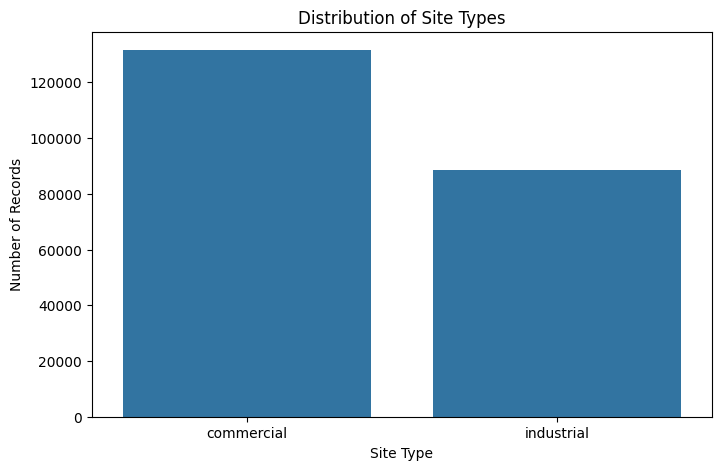

In [221]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df,x='site_type')

plt.title("Distribution of Site Types")
plt.xlabel("Site Type")
plt.ylabel("Number of Records")

plt.show()

In [222]:
df['site_id'].value_counts().describe()

,count
count,220000.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


In [223]:
df['site_id'].value_counts().head(10)

,count
site_id,
IND-00219945,1
IND-00219944,1
IND-00219943,1
IND-00219941,1
IND-00219940,1
IND-00219938,1
IND-00219937,1
IND-00219932,1
IND-00219931,1


In [224]:
# Check records per timestamp
timestamp_counts = df['timestamp'].value_counts()

print(timestamp_counts.describe())

count    8760.000000
mean       25.114155
std         5.051192
min        10.000000
25%        22.000000
50%        25.000000
75%        29.000000
max        46.000000
Name: count, dtype: float64


In [225]:
# Check how many records exist at each timestamp
print(timestamp_counts.head(10))

timestamp
2024-07-09 03:00:00    46
2024-06-18 02:00:00    45
2024-08-28 02:00:00    45
2024-11-07 16:00:00    44
2024-03-20 10:00:00    44
2024-01-23 06:00:00    44
2024-10-13 02:00:00    44
2024-01-15 22:00:00    43
2024-08-10 17:00:00    42
2024-03-15 23:00:00    42
Name: count, dtype: int64


In [226]:
# Check unique timestamps
print("Unique timestamps:", df['timestamp'].nunique())
print("Total rows:", len(df))

Unique timestamps: 8760
Total rows: 220000


In [227]:
print(df['site_type'].value_counts())

site_type
commercial    131577
industrial     88423
Name: count, dtype: int64


In [228]:
# Step: Create Hourly Aggregated Dataset

hourly_df = df.groupby('timestamp').agg(
    total_energy_kwh = ('energy_kwh','sum'),
    commercial_energy_kwh = ('energy_kwh',lambda x: x[df.loc[x.index,'site_type'] == 'commercial'].sum()),
    industrical_energy_kwh = ('energy_kwh', lambda x: x[df.loc[x.index,'site_type'] == 'industrial'].sum())
).reset_index()

hourly_df.head()

,timestamp,total_energy_kwh,commercial_energy_kwh,industrical_energy_kwh
0,2024-01-01 00:00:00,3199.524,366.539,2832.985
1,2024-01-01 01:00:00,3449.126,526.545,2922.581
2,2024-01-01 02:00:00,2206.027,473.599,1732.428
3,2024-01-01 03:00:00,3089.685,346.188,2743.497
4,2024-01-01 04:00:00,1863.971,395.748,1468.223


In [229]:
hourly_df.shape

(8760, 4)

In [230]:
hourly_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   timestamp               8760 non-null   datetime64[ns]
 1   total_energy_kwh        8760 non-null   float64       
 2   commercial_energy_kwh   8760 non-null   float64       
 3   industrical_energy_kwh  8760 non-null   float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 273.9 KB


In [231]:
hourly_df.describe()

,timestamp,total_energy_kwh,commercial_energy_kwh,industrical_energy_kwh
count,8760,8760.000000,8760.000000,8760.000000
mean,2024-07-01 11:30:00,4492.265701,581.258442,3911.007258
min,2024-01-01 00:00:00,533.048000,66.407000,214.690000
25%,2024-04-01 05:45:00,3042.339500,399.862500,2570.814250
50%,2024-07-01 11:30:00,4267.248500,550.122500,3667.896000
75%,2024-09-30 17:15:00,5676.588000,732.780250,4985.621000
max,2024-12-30 23:00:00,14295.903000,1702.583000,13352.767000
std,NaN,1905.527455,238.995403,1796.462057


In [232]:
hourly_df.isnull().sum()

,0
timestamp,0
total_energy_kwh,0
commercial_energy_kwh,0
industrical_energy_kwh,0


In [233]:
print("duplicate timeatamps: ",hourly_df['timestamp'].duplicated().sum())

duplicate timeatamps:  0


In [234]:
expected_hours = pd.date_range(
    start=hourly_df['timestamp'].min(),
    end=hourly_df['timestamp'].max(),
    freq='h'
)

missing_hours = expected_hours.difference(
    hourly_df['timestamp']
)

print("Expected hours:", len(expected_hours))
print("Actual hours:", len(hourly_df))
print("Missing hours:", len(missing_hours))

Expected hours: 8760
Actual hours: 8760
Missing hours: 0


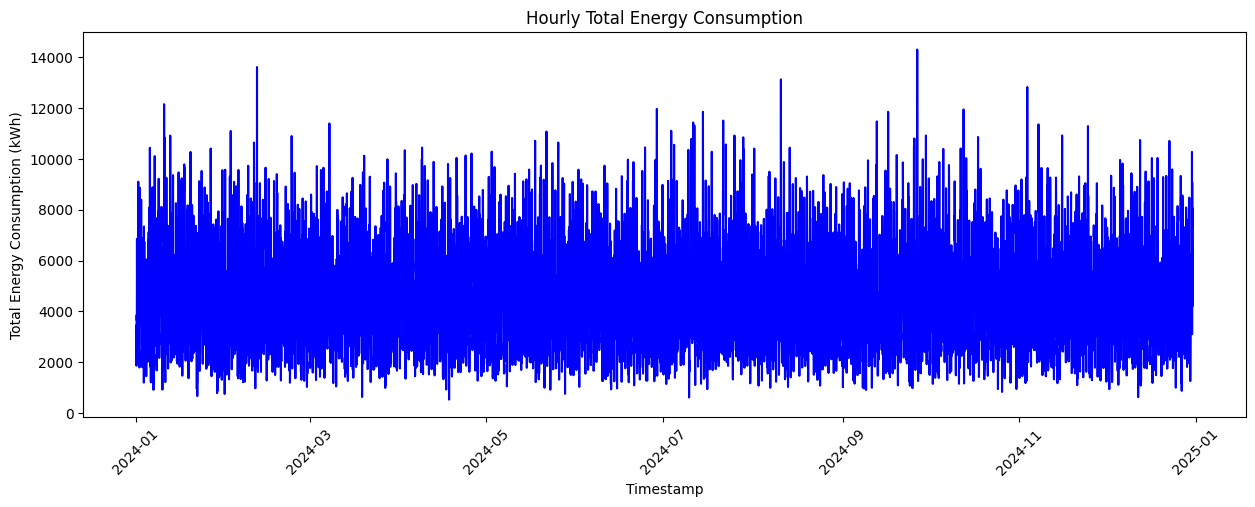

In [235]:
plt.figure(figsize=(15, 5))
plt.plot(
    hourly_df['timestamp'],
    hourly_df['total_energy_kwh'],
    linestyle='-',
    color='b'
)
plt.title("Hourly Total Energy Consumption")
plt.xlabel("Timestamp")
plt.ylabel("Total Energy Consumption (kWh)")
plt.xticks(rotation=45)

plt.show()

In [236]:
hourly_df['hour'] = hourly_df['timestamp'].dt.hour

In [237]:
hourly_pattern = (
    hourly_df.groupby('hour')['total_energy_kwh']
    .mean()
)

hourly_pattern

,total_energy_kwh
hour,
0,2954.420148
1,2814.563195
2,2379.499178
3,2436.806455
4,2659.134452
5,3211.124781
6,3713.724515
7,4103.303068
8,4702.291663


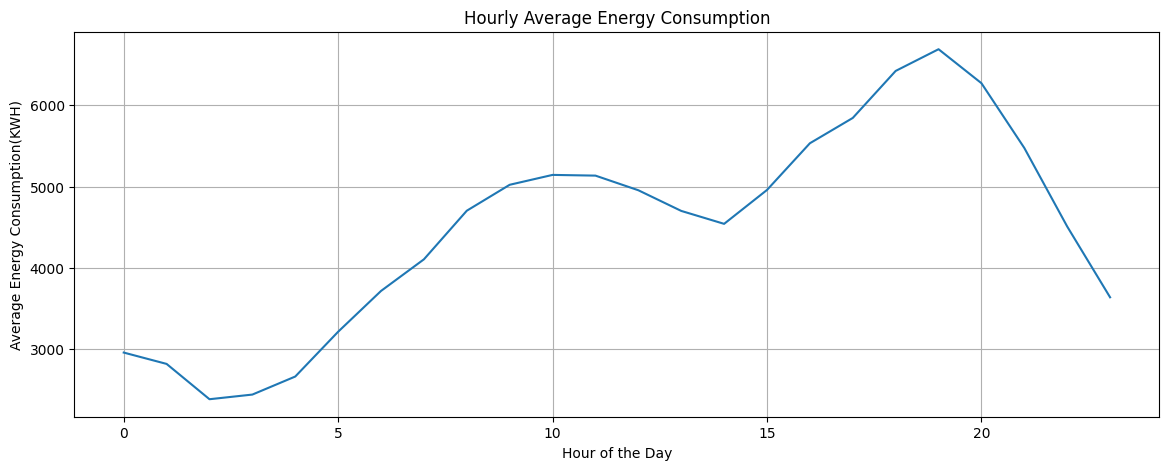

In [238]:
plt.figure(figsize=(14,5))

plt.plot(
    hourly_pattern.index,
    hourly_pattern.values,
)
plt.title("Hourly Average Energy Consumption")
plt.xlabel('Hour of the Day')
plt.ylabel('Average Energy Consumption(KWH)')
plt.grid(True)
plt.show()

In [239]:
hourly_df['day_of_week'] = hourly_df['timestamp'].dt.dayofweek

In [240]:
day_pattern = (
    hourly_df.groupby('day_of_week')['total_energy_kwh']
    .mean()

)
day_pattern

,total_energy_kwh
day_of_week,
0,4526.498201
1,4477.279068
2,4471.030919
3,4453.836692
4,4482.046690
5,4496.635140
6,4537.874877


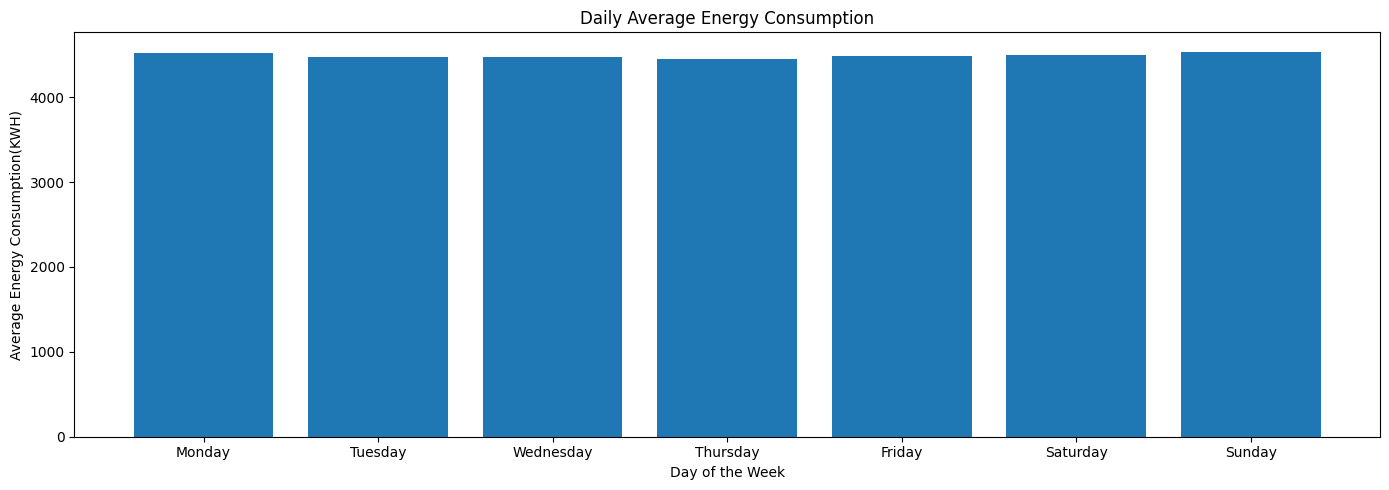

In [241]:
days = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

plt.figure(figsize = (14,5))
plt.bar(
    days,
    day_pattern.values
)
plt.title('Daily Average Energy Consumption')
plt.xlabel('Day of the Week')
plt.ylabel('Average Energy Consumption(KWH)')
plt.tight_layout()
plt.show()

In [242]:
hourly_df['month'] = hourly_df['timestamp'].dt.month

In [243]:
monthly_pattern = (
    hourly_df.groupby('month')['total_energy_kwh'].mean()
)

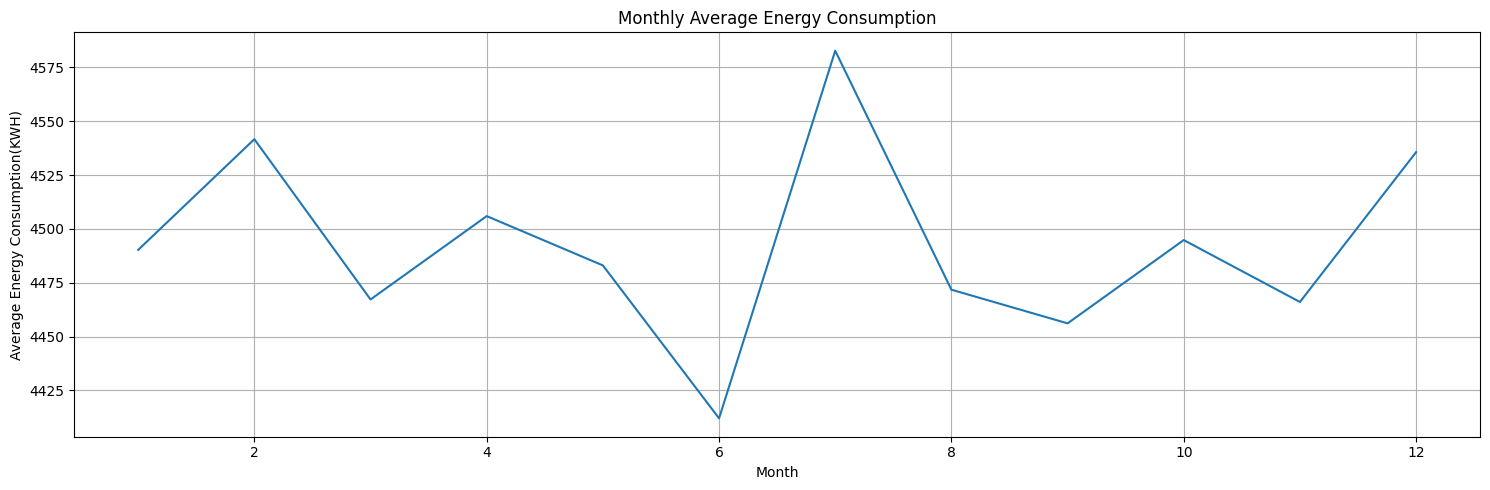

In [244]:
plt.figure(figsize =(15,5))

plt.plot(
    monthly_pattern.index,
    monthly_pattern.values,
)
plt.title('Monthly Average Energy Consumption')
plt.xlabel('Month')
plt.ylabel('Average Energy Consumption(KWH)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [245]:
# Commercial vs Industrial Consumption

commercial_avg = hourly_df['commercial_energy_kwh'].mean()
industrial_avg = hourly_df['industrical_energy_kwh'].mean()

print("Average Commercial Energy:", commercial_avg)
print("Average Industrial Energy:", industrial_avg)

Average Commercial Energy: 581.2584423515982
Average Industrial Energy: 3911.0072582191783


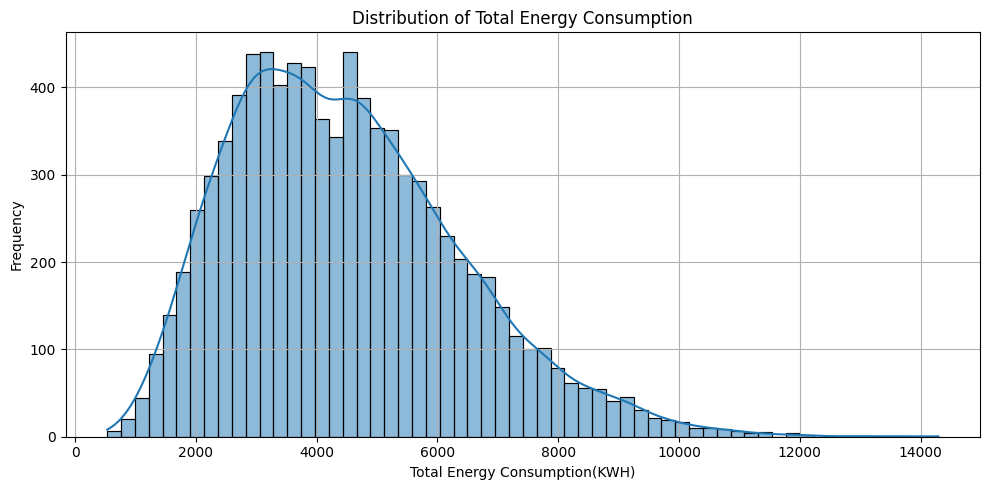

In [246]:
plt.figure(figsize = (10,5))

sns.histplot(
    hourly_df['total_energy_kwh'],
    bins = 60,
    kde = True
)


plt.title('Distribution of Total Energy Consumption')
plt.xlabel('Total Energy Consumption(KWH)')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

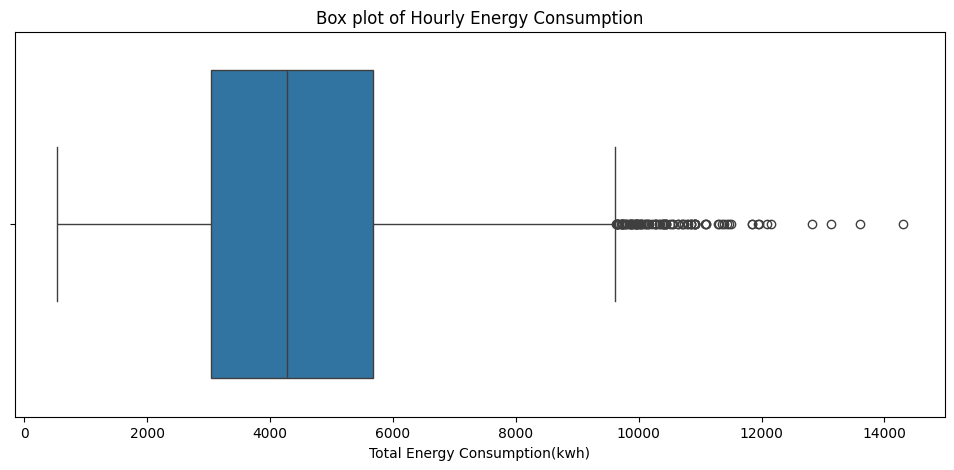

In [247]:
plt.figure(figsize = (12,5))

sns.boxplot(
    x = hourly_df['total_energy_kwh']
)
plt.title('Box plot of Hourly Energy Consumption')
plt.xlabel("Total Energy Consumption(kwh)")

plt.show()

In [248]:
hourly_df['rolling_mean_24'] = (
    hourly_df['total_energy_kwh']
    .rolling(window=24)
    .mean()
)

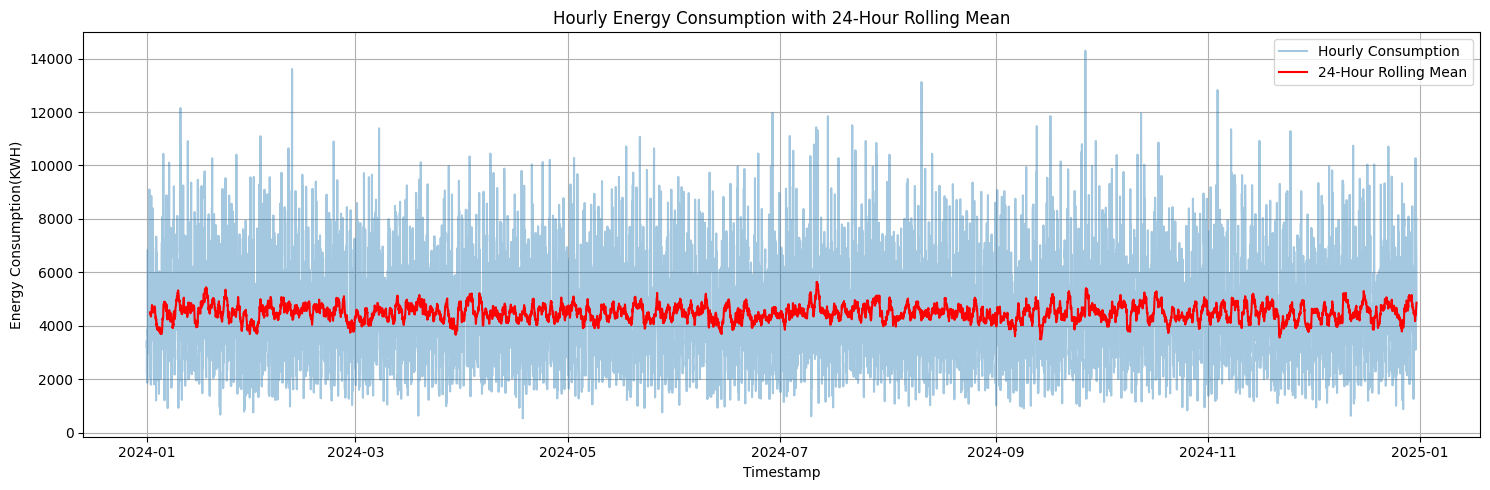

In [249]:
plt.figure(figsize=(15,5))

plt.plot(
    hourly_df['timestamp'],
    hourly_df['total_energy_kwh'],
    alpha = 0.4,
    label='Hourly Consumption'
    )

plt.plot(
    hourly_df['timestamp'],
    hourly_df['rolling_mean_24'],
    color = 'red',
    label = '24-Hour Rolling Mean'
)

plt.title('Hourly Energy Consumption with 24-Hour Rolling Mean')
plt.xlabel('Timestamp')
plt.ylabel('Energy Consumption(KWH)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [250]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

<Figure size 1200x500 with 0 Axes>

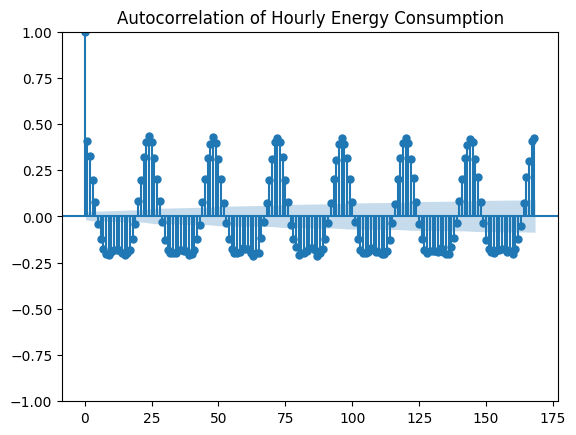

In [251]:
# Autocorrelation

plt.figure(figsize=(12, 5))

plot_acf(
    hourly_df['total_energy_kwh'].dropna(),
    lags=168
)

plt.title("Autocorrelation of Hourly Energy Consumption")
plt.show()

<Figure size 1200x500 with 0 Axes>

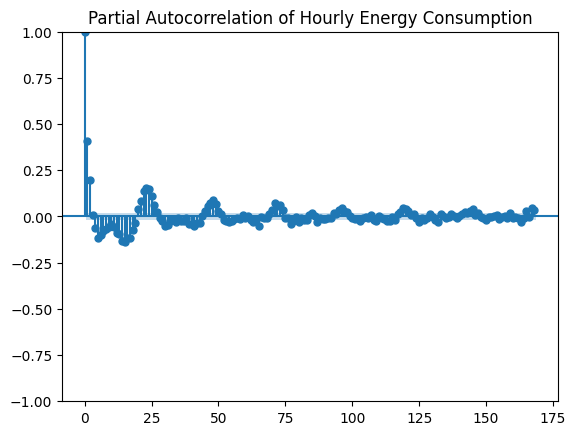

In [252]:
# Partial Correlation

plt.figure(figsize=(12, 5))

plot_pacf(
    hourly_df['total_energy_kwh'].dropna(),
    lags=168,
    method ='ywm'
)

plt.title("Partial Autocorrelation of Hourly Energy Consumption")
plt.show()

In [253]:
from statsmodels.tsa.stattools import adfuller

# Augmented Dickey-Fuller Test

result = adfuller(
    hourly_df['total_energy_kwh'].dropna()
)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -15.609072313113508
p-value: 1.7893074254118374e-28


In [254]:
print("\nCritical Values:")

for key, value in result[4].items():
    print(f"{key}: {value}")


Critical Values:
1%: -3.431099882538333
5%: -2.8618713981324873
10%: -2.56694639826003


In [255]:
hourly_df = hourly_df.sort_values(
    'timestamp'
).reset_index(drop=True)

hourly_df.head()

,timestamp,total_energy_kwh,commercial_energy_kwh,industrical_energy_kwh,hour,day_of_week,month,rolling_mean_24
0,2024-01-01 00:00:00,3199.524,366.539,2832.985,0,0,1,NaN
1,2024-01-01 01:00:00,3449.126,526.545,2922.581,1,0,1,NaN
2,2024-01-01 02:00:00,2206.027,473.599,1732.428,2,0,1,NaN
3,2024-01-01 03:00:00,3089.685,346.188,2743.497,3,0,1,NaN
4,2024-01-01 04:00:00,1863.971,395.748,1468.223,4,0,1,NaN


In [256]:
hourly_df['hour'] = hourly_df['timestamp'].dt.hour
hourly_df['day_of_week'] = hourly_df['timestamp'].dt.dayofweek
hourly_df['month'] = hourly_df['timestamp'].dt.month
hourly_df['is_weekend'] = (
    hourly_df['day_of_week'] >=5
).astype(int)

In [257]:
#Lag Features

hourly_df['lag_1'] = hourly_df['total_energy_kwh'].shift(1)
hourly_df['lag_24'] = hourly_df['total_energy_kwh'].shift(24)
hourly_df['lag_168'] = hourly_df['total_energy_kwh'].shift(168)

In [258]:
hourly_df['rolling_mean_24'] = (
    hourly_df['total_energy_kwh'].shift(1).rolling(window = 24).mean()
)

In [259]:
hourly_df = hourly_df.dropna().reset_index(drop=True)

print("Shape after feature engineering:", hourly_df.shape)

Shape after feature engineering: (8592, 12)


In [260]:
X = hourly_df[
    [
        'hour',
        'day_of_week',
        'month',
        'is_weekend',
        'lag_1',
        'lag_24',
        'lag_168',
        'rolling_mean_24'
    ]
]

y = hourly_df['total_energy_kwh']

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (8592, 8)
Shape of y: (8592,)


In [261]:
# Chronological Train-Test Split

split_index = int(len(X) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (6873, 8)
X_test : (1719, 8)
y_train: (6873,)
y_test : (1719,)


In [262]:
naive_predictions = y_test.shift(1)
naive_predictions.iloc[0] = y_train.iloc[-1]

In [263]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
naive_mae = mean_absolute_error(
    y_test,
    naive_predictions
)

naive_rmse =  np.sqrt(
    mean_squared_error(
        y_test,
        naive_predictions
    )
)

naive_mape = np.mean(
    np.abs(
        (y_test - naive_predictions) / y_test
    )
) * 100


print("Naive Model Performance")
print("-----------------------")
print("MAE :", naive_mae)
print("RMSE:", naive_rmse)
print("MAPE:", naive_mape, "%")

Naive Model Performance
-----------------------
MAE : 1526.5227434554972
RMSE: 1997.7743396504395
MAPE: 38.74711242487129 %


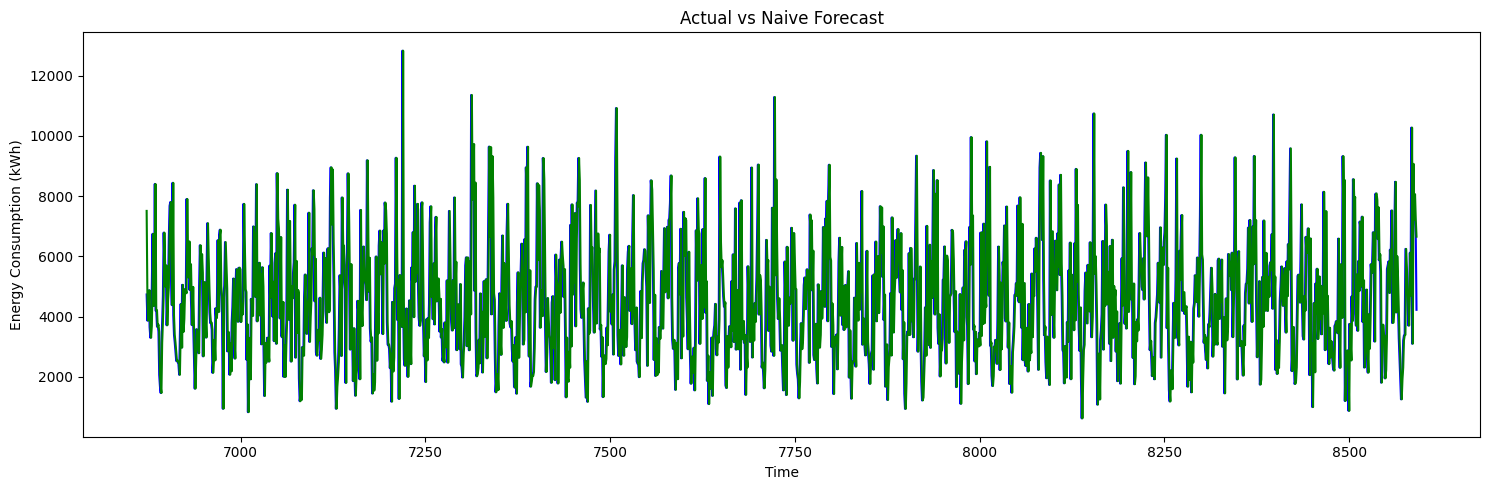

In [264]:
plt.figure(figsize=(15, 5))

plt.plot(
    y_test.index,
    y_test.values,
    label='Actual',
    color = 'blue'
)

plt.plot(
    naive_predictions.index,
    naive_predictions.values,
    label='Naive Forecast',
    color = 'green'
)

plt.title("Actual vs Naive Forecast")
plt.xlabel("Time")
plt.ylabel("Energy Consumption (kWh)")

plt.tight_layout()
plt.show()

In [265]:
# Step: Import ARIMA

from statsmodels.tsa.arima.model import ARIMA

print("ARIMA imported successfully!")

ARIMA imported successfully!


In [266]:
arima_model = ARIMA(
  y_train,
  order = (1,0,1)
)

arima_model_fit = arima_model.fit()
print(arima_model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:       total_energy_kwh   No. Observations:                 6873
Model:                 ARIMA(1, 0, 1)   Log Likelihood              -60980.984
Date:                Thu, 01 Oct 2026   AIC                         121969.968
Time:                        08:42:57   BIC                         121997.310
Sample:                             0   HQIC                        121979.398
                               - 6873                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       4495.7808     49.271     91.246      0.000    4399.211    4592.350
ar.L1          0.6752      0.020     33.053      0.000       0.635       0.715
ma.L1         -0.3215      0.026    -12.591      0.0

In [267]:
arima_predictions = arima_model_fit.forecast(
    steps=len(y_test)
)

print("ARIMA predictions generated successfully!")

ARIMA predictions generated successfully!


In [268]:
arima_predictions.head()

,predicted_mean
6873,5179.963587
6874,4957.738815
6875,4807.693367
6876,4706.383165
6877,4637.978843


In [269]:
arima_mae = mean_absolute_error(
    y_test,
    arima_predictions
)

arima_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        arima_predictions
    )
)

arima_mape = np.mean(
    np.abs(
        (y_test - arima_predictions) / y_test
    )
) * 100

print("ARIMA Model Performance")
print("-----------------------")
print("MAE :", arima_mae)
print("RMSE:", arima_rmse)
print("MAPE:", arima_mape, "%")

ARIMA Model Performance
-----------------------
MAE : 1509.6107865062327
RMSE: 1876.0374621309734
MAPE: 43.80583985358571 %


In [270]:
# Step: Compare Naive and ARIMA

model_results = pd.DataFrame({
    'Model': [
        'Naive',
        'ARIMA(1,0,1)'
    ],
    'MAE': [
        naive_mae,
        arima_mae
    ],
    'RMSE': [
        naive_rmse,
        arima_rmse
    ],
    'MAPE': [
        naive_mape,
        arima_mape
    ]
})

model_results

,Model,MAE,RMSE,MAPE
0,Naive,1526.522743,1997.774340,38.747112
1,"ARIMA(1,0,1)",1509.610787,1876.037462,43.805840


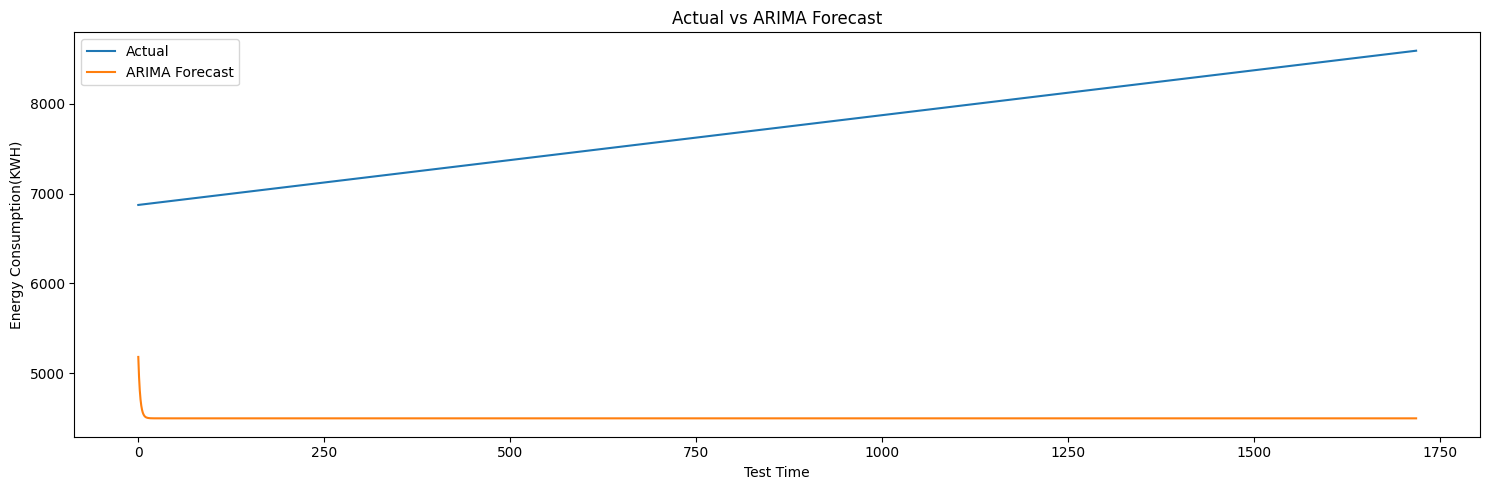

In [271]:
plt.figure(figsize = (15,5))

plt.plot(
    y_test.index,
    label = 'Actual'
)

plt.plot(
    arima_predictions.values,
    label = 'ARIMA Forecast'
)

plt.title('Actual vs ARIMA Forecast')
plt.xlabel('Test Time')
plt.ylabel('Energy Consumption(KWH)')
plt.tight_layout()
plt.legend()
plt.show()

In [272]:
print("------------ARIMA  Vs  naive-----------")
print()
print(arima_mae," ",naive_mae)
print(arima_rmse," ",naive_rmse)
print(arima_mape," ",naive_mape)

------------ARIMA  Vs  naive-----------

1509.6107865062327   1526.5227434554972
1876.0374621309734   1997.7743396504395
43.80583985358571   38.74711242487129


In [273]:
# Import SARIMA

from statsmodels.tsa.statespace.sarimax import SARIMAX

print("SARIMA imported successfully!")

SARIMA imported successfully!


In [274]:
sarima_model = SARIMAX(
    y_train,
    order = (1,0,1),
    seasonal_order = (1,0,1,24),
    enforce_stationarity = False,
    enforce_invertibility = False
)

sarima_model_fit = sarima_model.fit(
    disp =False
)

print("SARIMA model fit successfully!")

SARIMA model fit successfully!


In [275]:
#SARIMA Predictions
sarima_predictions = sarima_model_fit.forecast(
    steps=len(y_test)
)

print("SARIMA predictions generated successfully!")

SARIMA predictions generated successfully!


In [276]:
sarima_predictions.head()

,predicted_mean
6873,4870.149208
6874,5103.453006
6875,5052.175679
6876,4873.111401
6877,4667.993369


In [277]:
sarima_mae = mean_absolute_error(
    y_test,
    sarima_predictions
)

sarima_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        sarima_predictions
    )
)

sarima_mape = np.mean(
    np.abs(
        (y_test - sarima_predictions) / y_test
    )
) * 100

print("SARIMA Model Performance")
print("-----------------------")
print("MAE :", sarima_mae)
print("RMSE:", sarima_rmse)
print("MAPE:", sarima_mape, "%")

SARIMA Model Performance
-----------------------
MAE : 1098.079603100942
RMSE: 1418.5520230919437
MAPE: 28.834349173115253 %


In [278]:
#Model Comparison

model_results = pd.DataFrame({
    'Model': [
        'Naive',
        'ARIMA(1,0,1)',
        'SARIMA(1,0,1)(1,0,1,24)'
    ],
    'MAE': [
        naive_mae,
        arima_mae,
        sarima_mae
    ],
    'RMSE': [
        naive_rmse,
        arima_rmse,
        sarima_rmse
    ],
    'MAPE': [
        naive_mape,
        arima_mape,
        sarima_mape
    ]
})

model_results

,Model,MAE,RMSE,MAPE
0,Naive,1526.522743,1997.774340,38.747112
1,"ARIMA(1,0,1)",1509.610787,1876.037462,43.805840
2,"SARIMA(1,0,1)(1,0,1,24)",1098.079603,1418.552023,28.834349


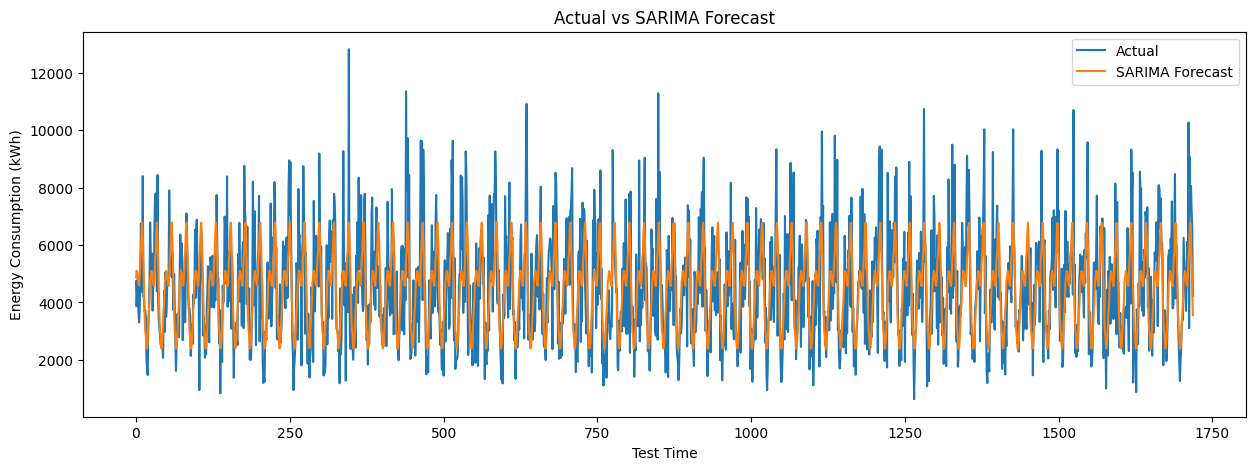

In [279]:
# Step 36: Actual vs SARIMA Forecast

plt.figure(figsize=(15, 5))

plt.plot(
    y_test.values,
    label='Actual'
)

plt.plot(
    sarima_predictions.values,
    label='SARIMA Forecast'
)

plt.title("Actual vs SARIMA Forecast")
plt.xlabel("Test Time")
plt.ylabel("Energy Consumption (kWh)")

plt.legend()
plt.show()

In [280]:
!pip install -q xgboost

from xgboost import XGBRegressor

print("XGBoost imported successfully!")

XGBoost imported successfully!


In [281]:
# Step: Create XGBoost Model

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='reg:squarederror'
)

print("XGBoost model created successfully!")

XGBoost model created successfully!


In [282]:
xgb_model.fit(
    X_train,
    y_train,
)

print("XGBOOST model trained successfully!")

XGBOOST model trained successfully!


In [283]:
xgb_predictions = xgb_model.predict(X_test)

print("XGBoost predictions generated successfully!")

XGBoost predictions generated successfully!


In [284]:
xgb_predictions[:10]

array([5352.042 , 5496.9683, 5316.3623, 5104.941 , 5125.109 , 4981.9033,
       5014.017 , 5609.3926, 5709.9517, 7123.4644], dtype=float32)

In [285]:
xgb_mae = mean_absolute_error(
    y_test,
    xgb_predictions
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_predictions
    )
)

xgb_mape = np.mean(
    np.abs(
        (y_test - xgb_predictions) / y_test
    )
)*100


print("XGBoost Model Performance")
print("-------------------------")
print("MAE :", xgb_mae)
print("RMSE:", xgb_rmse)
print("MAPE:", xgb_mape, "%")

XGBoost Model Performance
-------------------------
MAE : 1138.6148499718222
RMSE: 1466.7022762737902
MAPE: 30.11217638881855 %


In [286]:
# Step 43: Final Model Comparison

model_results = pd.DataFrame({
    'Model': [
        'Naive',
        'ARIMA(1,0,1)',
        'SARIMA(1,0,1)(1,0,1,24)',
        'XGBoost'
    ],
    'MAE': [
        naive_mae,
        arima_mae,
        sarima_mae,
        xgb_mae
    ],
    'RMSE': [
        naive_rmse,
        arima_rmse,
        sarima_rmse,
        xgb_rmse
    ],
    'MAPE': [
        naive_mape,
        arima_mape,
        sarima_mape,
        xgb_mape
    ]
})

model_results

,Model,MAE,RMSE,MAPE
0,Naive,1526.522743,1997.774340,38.747112
1,"ARIMA(1,0,1)",1509.610787,1876.037462,43.805840
2,"SARIMA(1,0,1)(1,0,1,24)",1098.079603,1418.552023,28.834349
3,XGBoost,1138.614850,1466.702276,30.112176


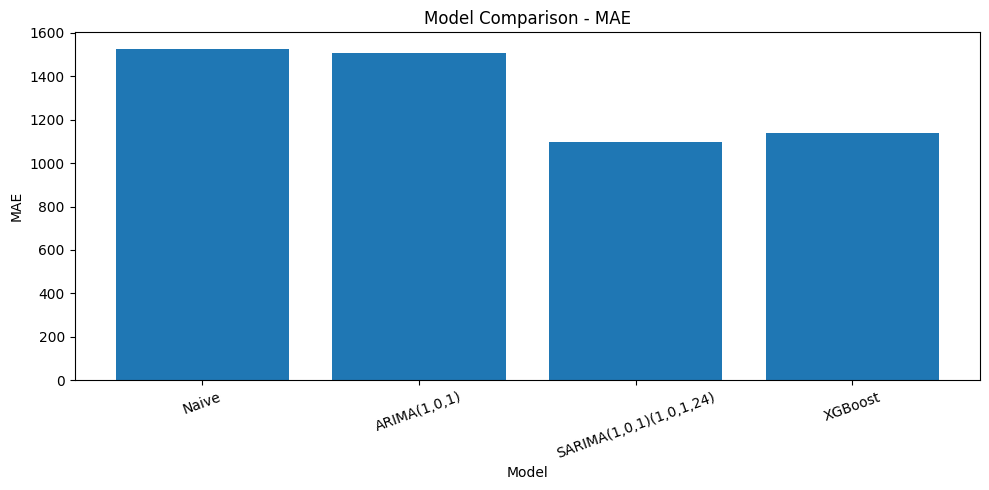

In [287]:
# Step: Compare MAE

plt.figure(figsize=(10, 5))

plt.bar(
    model_results['Model'],
    model_results['MAE']
)

plt.title("Model Comparison - MAE")
plt.xlabel("Model")
plt.ylabel("MAE")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

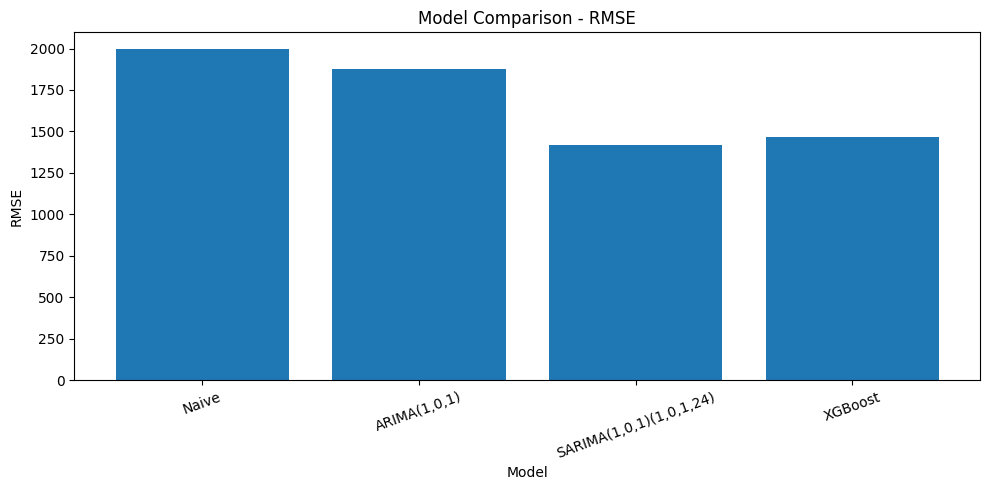

In [288]:
#RMSE
plt.figure(figsize=(10, 5))

plt.bar(
    model_results['Model'],
    model_results['RMSE']
)

plt.title("Model Comparison - RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

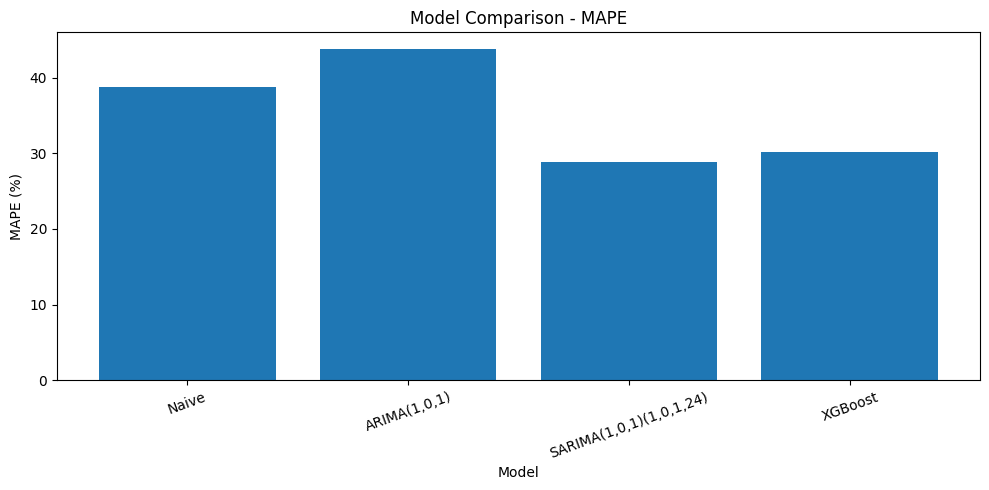

In [289]:
#MAPE
plt.figure(figsize=(10, 5))

plt.bar(
    model_results['Model'],
    model_results['MAPE']
)

plt.title("Model Comparison - MAPE")
plt.xlabel("Model")
plt.ylabel("MAPE (%)")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

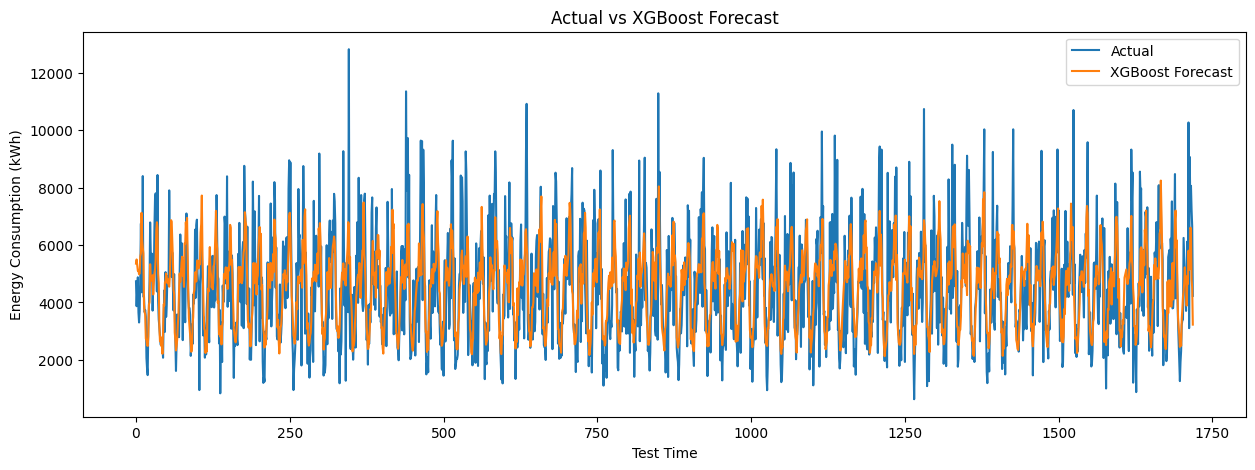

In [290]:
#Actual vs XGBoost Forecast

plt.figure(figsize=(15, 5))

plt.plot(
    y_test.values,
    label='Actual'
)

plt.plot(
    xgb_predictions,
    label='XGBoost Forecast'
)

plt.title("Actual vs XGBoost Forecast")
plt.xlabel("Test Time")
plt.ylabel("Energy Consumption (kWh)")

plt.legend()
plt.show()

In [291]:
#XGBoost Feature Importance

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    'Importance',
    ascending=False
)

feature_importance

,Feature,Importance
0,hour,0.480650
6,lag_168,0.106888
5,lag_24,0.101568
4,lag_1,0.090923
7,rolling_mean_24,0.072175
2,month,0.054400
1,day_of_week,0.051035
3,is_weekend,0.042361


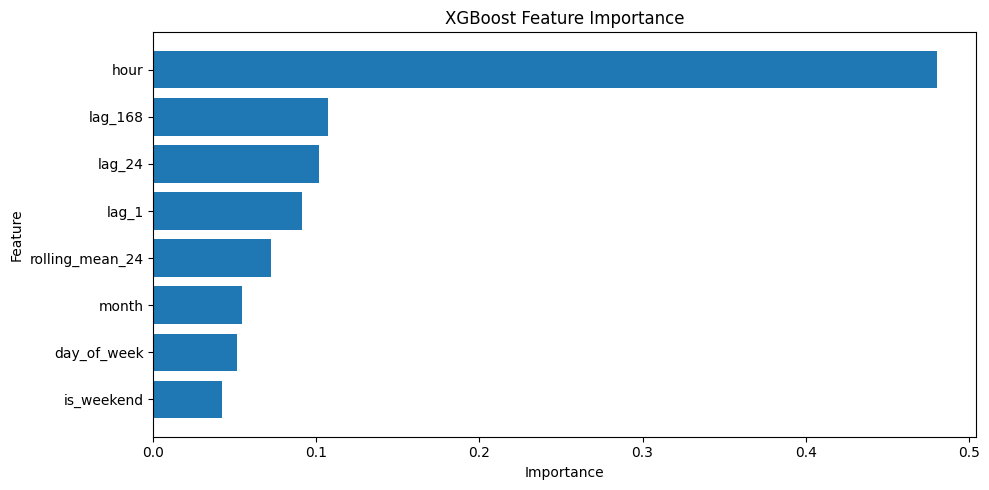

In [292]:
plt.figure(figsize=(10, 5))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [293]:
model_results

,Model,MAE,RMSE,MAPE
0,Naive,1526.522743,1997.774340,38.747112
1,"ARIMA(1,0,1)",1509.610787,1876.037462,43.805840
2,"SARIMA(1,0,1)(1,0,1,24)",1098.079603,1418.552023,28.834349
3,XGBoost,1138.614850,1466.702276,30.112176


In [294]:
#Create Forecast Results

forecast_results = pd.DataFrame({
    'timestamp': hourly_df.iloc[split_index:]['timestamp'].values,
    'actual': y_test.values,
    'sarima_forecast': sarima_predictions.values,
    'xgboost_forecast': xgb_predictions
})

forecast_results['sarima_error'] = (
    forecast_results['actual']
    - forecast_results['sarima_forecast']
)

forecast_results['xgboost_error'] = (
    forecast_results['actual']
    - forecast_results['xgboost_forecast']
)

forecast_results.head()

,timestamp,actual,sarima_forecast,xgboost_forecast,sarima_error,xgboost_error
0,2024-10-20 09:00:00,4737.302,4870.149208,5352.041992,-132.847208,-614.739992
1,2024-10-20 10:00:00,3869.441,5103.453006,5496.968262,-1234.012006,-1627.527262
2,2024-10-20 11:00:00,4431.487,5052.175679,5316.362305,-620.688679,-884.875305
3,2024-10-20 12:00:00,4876.656,4873.111401,5104.940918,3.544599,-228.284918
4,2024-10-20 13:00:00,3652.141,4667.993369,5125.108887,-1015.852369,-1472.967887


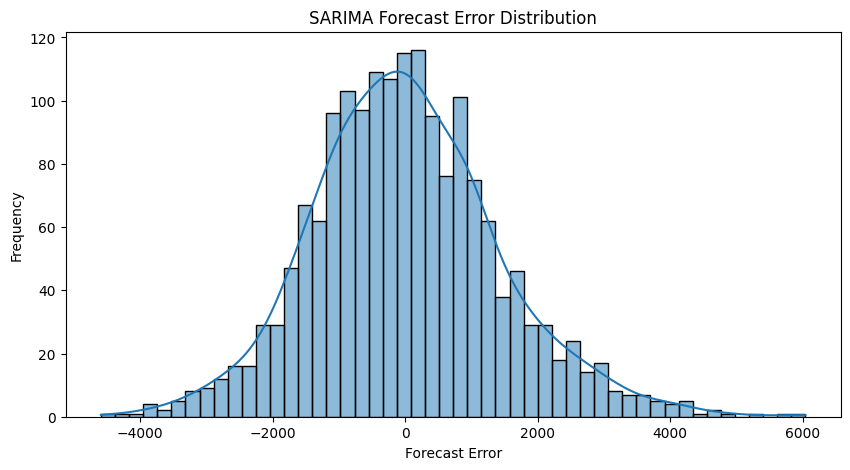

In [295]:
#SARIMA Error Distribution

plt.figure(figsize=(10, 5))

sns.histplot(
    forecast_results['sarima_error'],
    bins=50,
    kde=True
)

plt.title("SARIMA Forecast Error Distribution")
plt.xlabel("Forecast Error")
plt.ylabel("Frequency")

plt.show()

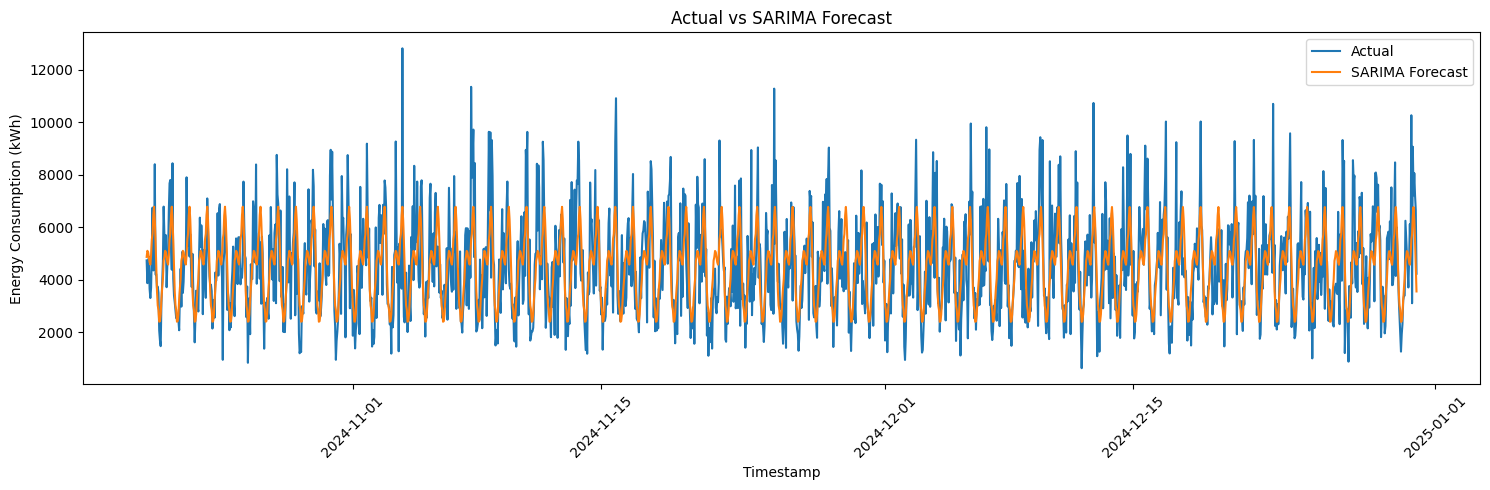

In [296]:
#Actual vs SARIMA Forecast

plt.figure(figsize=(15, 5))

plt.plot(
    forecast_results['timestamp'],
    forecast_results['actual'],
    label='Actual'
)

plt.plot(
    forecast_results['timestamp'],
    forecast_results['sarima_forecast'],
    label='SARIMA Forecast'
)

plt.title("Actual vs SARIMA Forecast")
plt.xlabel("Timestamp")
plt.ylabel("Energy Consumption (kWh)")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [297]:
#Calculate Absolute Error

forecast_results['absolute_error'] = (
    forecast_results['sarima_error'].abs()
)

forecast_results[['timestamp', 'actual', 'sarima_forecast', 'absolute_error']] \
    .sort_values('absolute_error', ascending=False) \
    .head(10)

,timestamp,actual,sarima_forecast,absolute_error
346,2024-11-03 19:00:00,12823.631,6782.184971,6041.446029
439,2024-11-07 16:00:00,11355.078,5537.546226,5817.531774
1524,2024-12-22 21:00:00,10705.697,5492.805846,5212.891154
849,2024-11-24 18:00:00,11286.371,6455.298312,4831.072688
1711,2024-12-30 16:00:00,10271.575,5528.536750,4743.038250
635,2024-11-15 20:00:00,10920.385,6299.040232,4621.344768
103,2024-10-24 16:00:00,946.574,5539.928538,4593.354538
1222,2024-12-10 07:00:00,8517.343,4033.247186,4484.095814
1475,2024-12-20 20:00:00,1921.465,6292.270542,4370.805542
1281,2024-12-12 18:00:00,10740.018,6451.729460,4288.288540


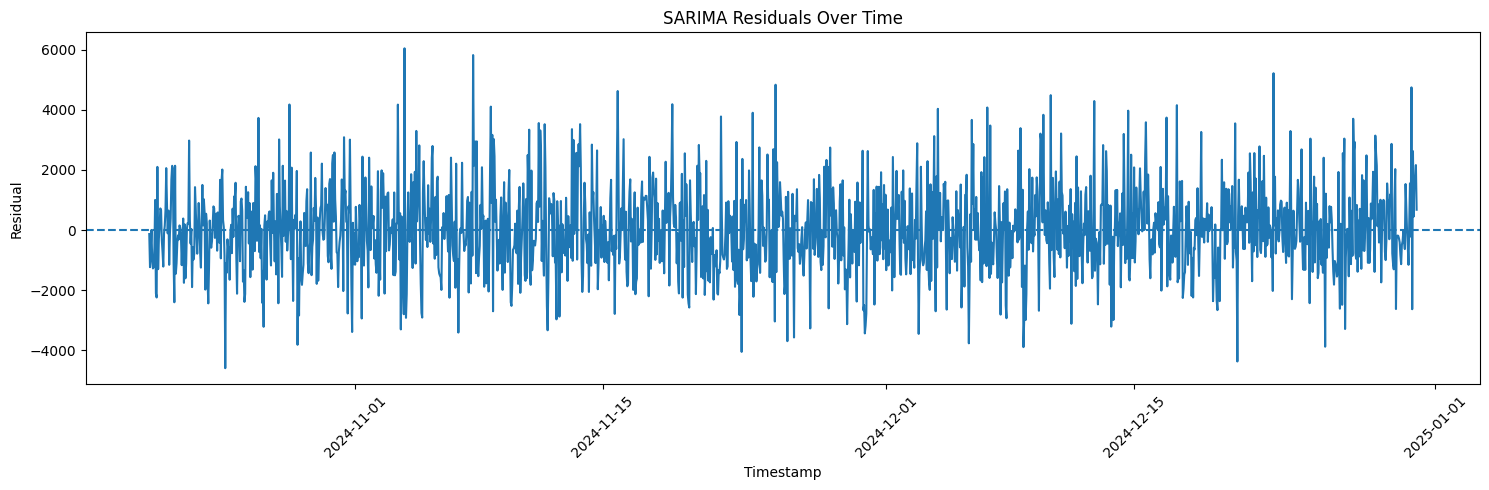

In [298]:
#SARIMA Residuals Over Time

plt.figure(figsize=(15, 5))

plt.plot(
    forecast_results['timestamp'],
    forecast_results['sarima_error']
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.title("SARIMA Residuals Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Residual")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

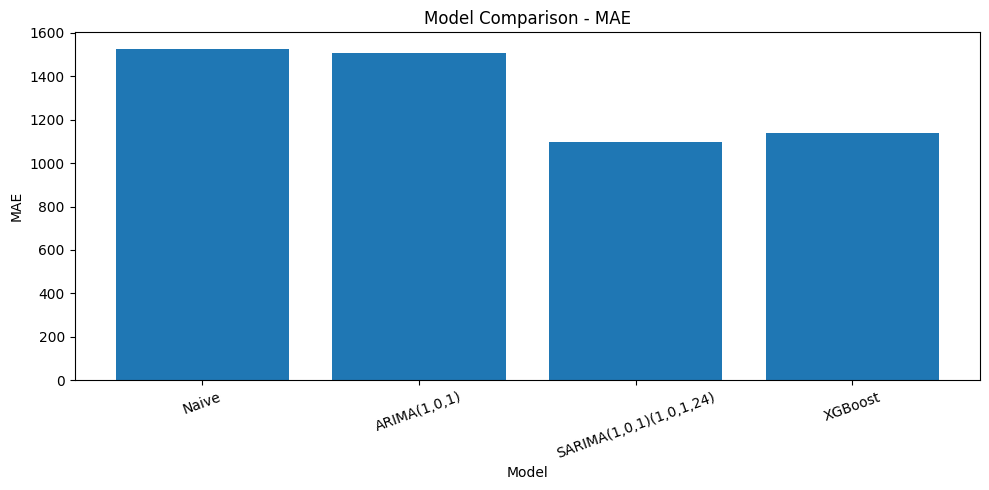

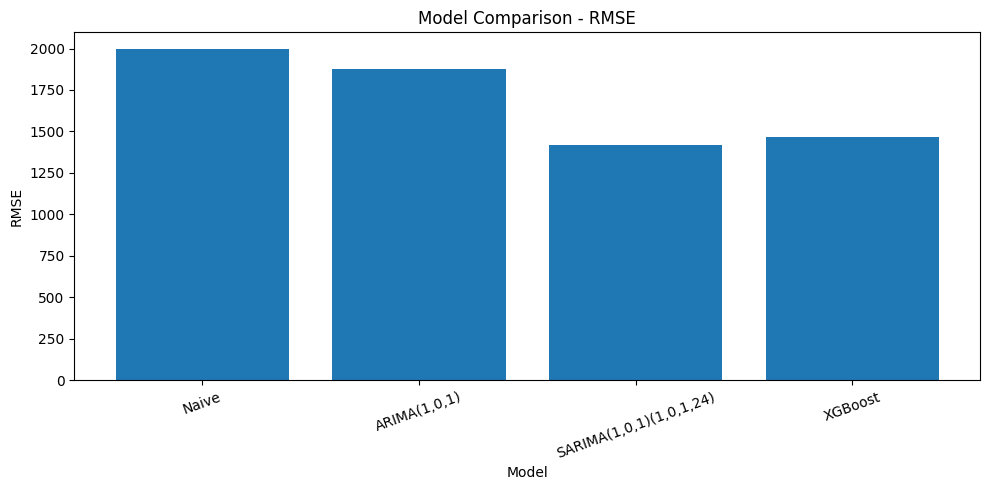

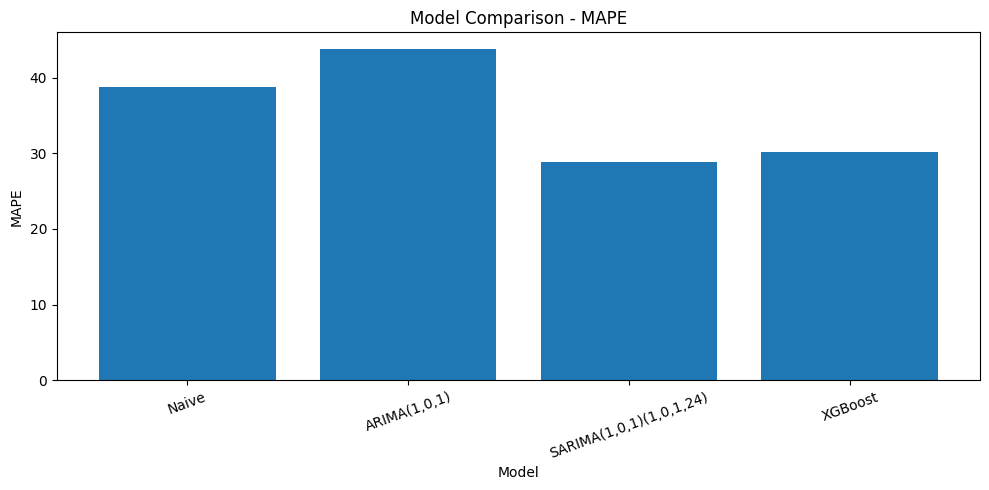

In [299]:
# Final Model Comparison

metrics = ['MAE', 'RMSE', 'MAPE']

for metric in metrics:
    plt.figure(figsize=(10, 5))

    plt.bar(
        model_results['Model'],
        model_results[metric]
    )

    plt.title(f"Model Comparison - {metric}")
    plt.xlabel("Model")
    plt.ylabel(metric)

    plt.xticks(rotation=20)
    plt.tight_layout()

    plt.show()

In [300]:
#Train Final SARIMA Model on Full Dataset

final_sarima_model = SARIMAX(
    hourly_df['total_energy_kwh'],
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_sarima_fit = final_sarima_model.fit(
    disp=False
)

print("Final SARIMA model trained successfully!")

Final SARIMA model trained successfully!


In [301]:
#Forecast Next 24 Hours

forecast_steps = 24

future_forecast = final_sarima_fit.forecast(
    steps=forecast_steps
)

future_forecast

,predicted_mean
8592,3033.487067
8593,2838.985763
8594,2407.730824
8595,2444.609194
8596,2678.723531
8597,3187.447230
8598,3690.785877
8599,4060.486239
8600,4667.880383
8601,5000.784617


In [302]:
#Create Future Timestamps

last_timestamp = hourly_df['timestamp'].max()

future_timestamps = pd.date_range(
    start=last_timestamp + pd.Timedelta(hours=1),
    periods=forecast_steps,
    freq='h'
)

future_forecast_df = pd.DataFrame({
    'timestamp': future_timestamps,
    'forecasted_energy_kwh': future_forecast.values
})

future_forecast_df

,timestamp,forecasted_energy_kwh
0,2024-12-31 00:00:00,3033.487067
1,2024-12-31 01:00:00,2838.985763
2,2024-12-31 02:00:00,2407.730824
3,2024-12-31 03:00:00,2444.609194
4,2024-12-31 04:00:00,2678.723531
5,2024-12-31 05:00:00,3187.447230
6,2024-12-31 06:00:00,3690.785877
7,2024-12-31 07:00:00,4060.486239
8,2024-12-31 08:00:00,4667.880383
9,2024-12-31 09:00:00,5000.784617


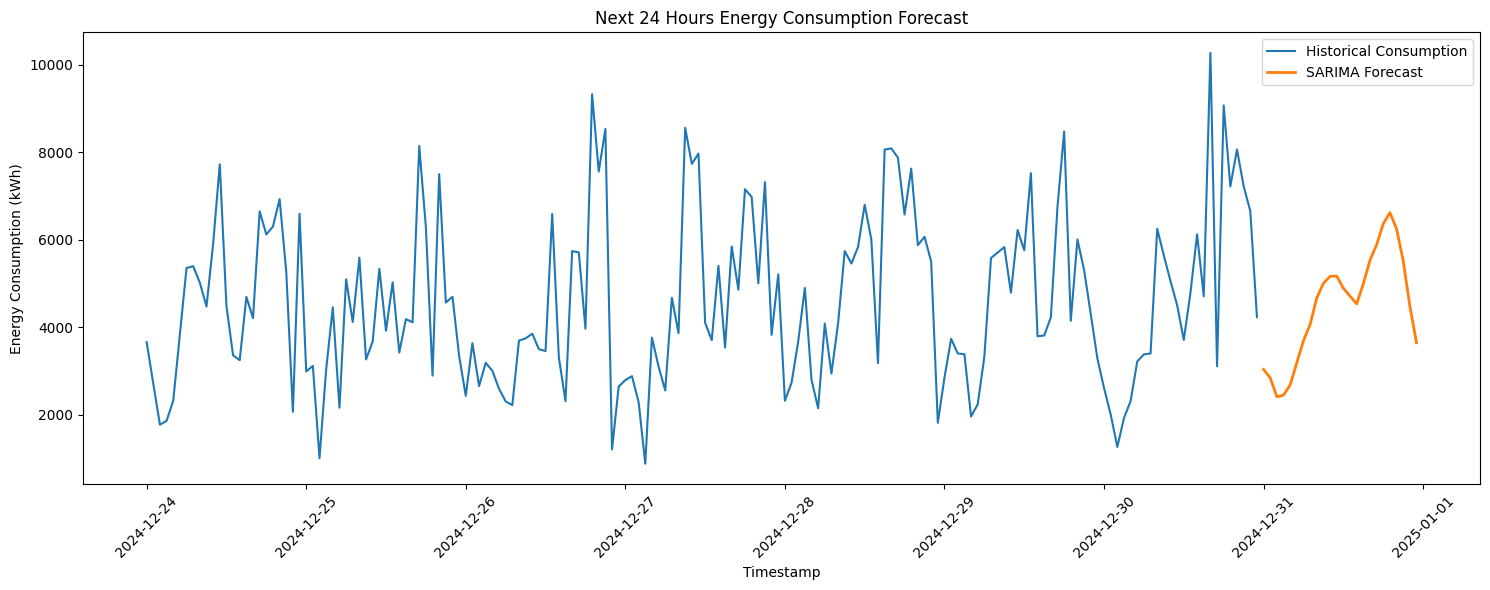

In [303]:
# Plot Future Forecast

plt.figure(figsize=(15, 6))

# Last 7 days of actual data
recent_data = hourly_df.tail(168)

plt.plot(
    recent_data['timestamp'],
    recent_data['total_energy_kwh'],
    label='Historical Consumption'
)

# Future forecast
plt.plot(
    future_forecast_df['timestamp'],
    future_forecast_df['forecasted_energy_kwh'],
    label='SARIMA Forecast',
    linewidth=2
)

plt.title("Next 24 Hours Energy Consumption Forecast")
plt.xlabel("Timestamp")
plt.ylabel("Energy Consumption (kWh)")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [304]:
#Save Forecast

future_forecast_df.to_csv(
    'energy_consumption_forecast.csv',
    index=False
)

print("Forecast saved successfully!")

Forecast saved successfully!


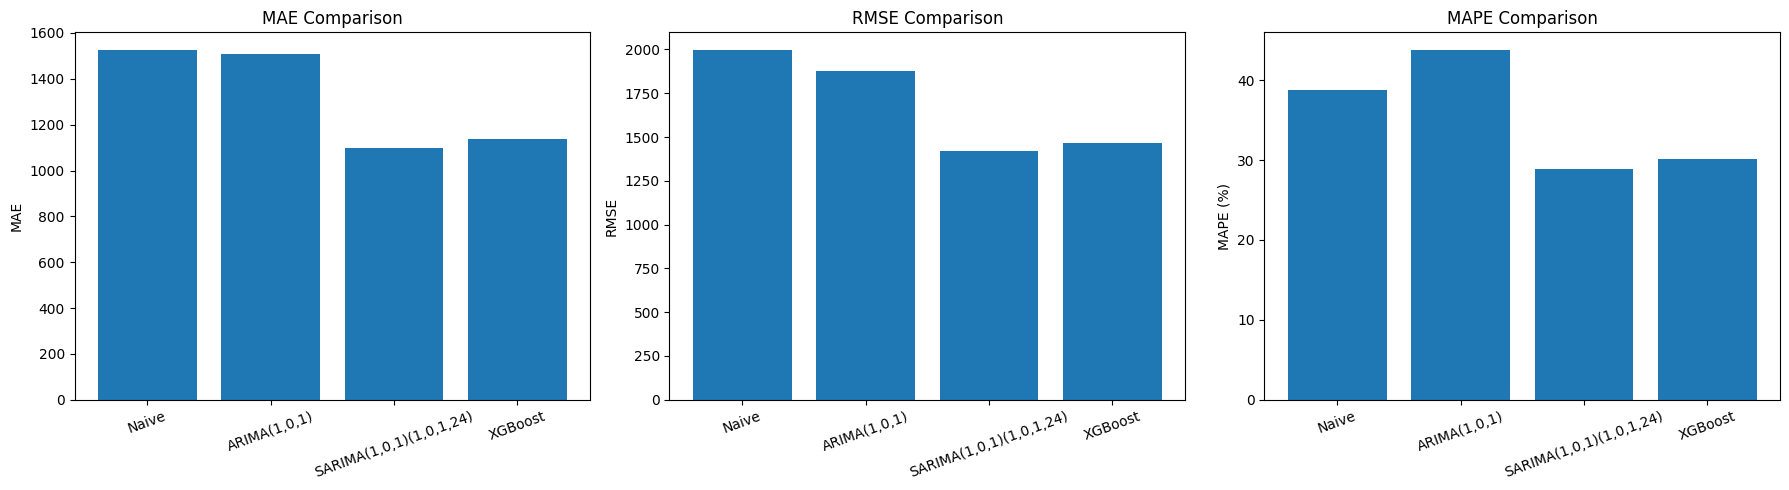

In [305]:
# Step 60: Model Performance Comparison

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# MAE
axes[0].bar(
    model_results['Model'],
    model_results['MAE']
)
axes[0].set_title('MAE Comparison')
axes[0].set_ylabel('MAE')
axes[0].tick_params(axis='x', rotation=20)

# RMSE
axes[1].bar(
    model_results['Model'],
    model_results['RMSE']
)
axes[1].set_title('RMSE Comparison')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=20)

# MAPE
axes[2].bar(
    model_results['Model'],
    model_results['MAPE']
)
axes[2].set_title('MAPE Comparison')
axes[2].set_ylabel('MAPE (%)')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

In [306]:
#Forecast Summary

print("Forecast Period:")
print(
    future_forecast_df['timestamp'].min(),
    "to",
    future_forecast_df['timestamp'].max()
)

print("\nAverage Forecasted Energy:",
      future_forecast_df['forecasted_energy_kwh'].mean())

print("Maximum Forecasted Energy:",
      future_forecast_df['forecasted_energy_kwh'].max())

print("Minimum Forecasted Energy:",
      future_forecast_df['forecasted_energy_kwh'].min())

Forecast Period:
2024-12-31 00:00:00 to 2024-12-31 23:00:00

Average Forecasted Energy: 4489.324315731869
Maximum Forecasted Energy: 6619.029479512163
Minimum Forecasted Energy: 2407.7308239543077


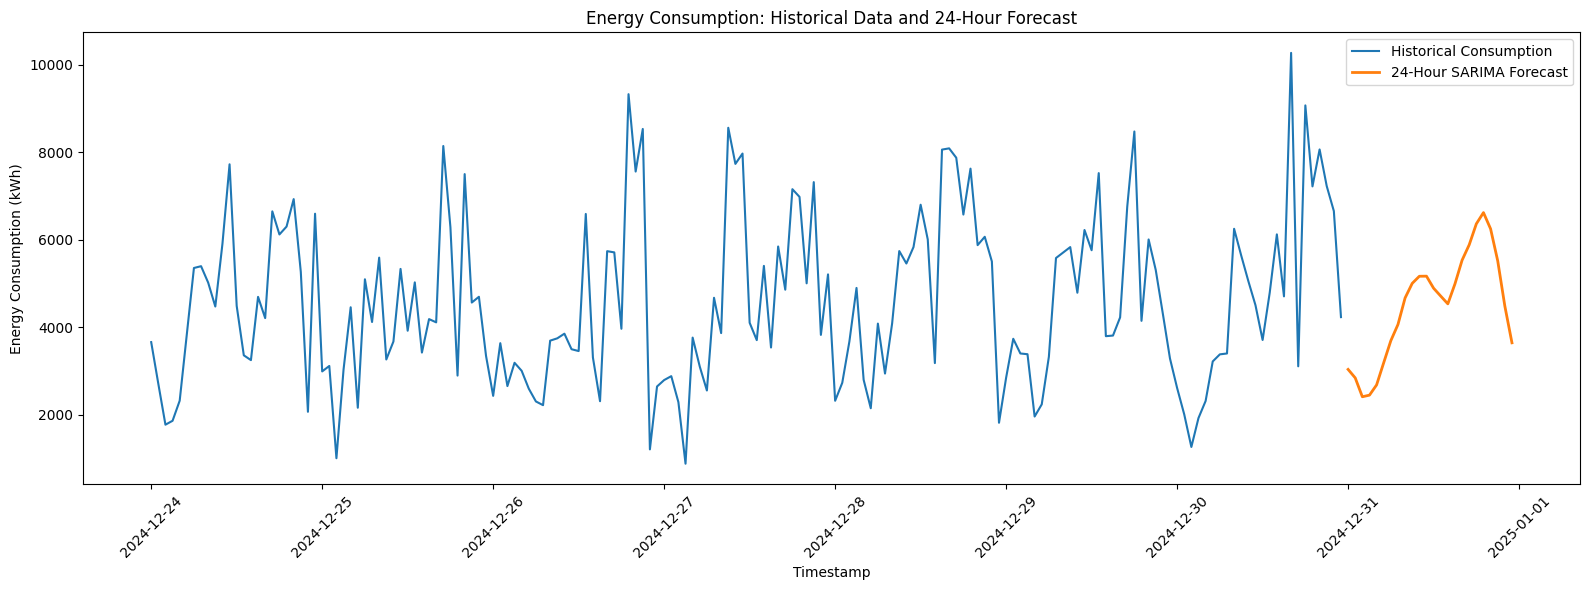

In [307]:
#Historical Data + Future Forecast

recent_data = hourly_df.tail(168)

plt.figure(figsize=(16, 6))

plt.plot(
    recent_data['timestamp'],
    recent_data['total_energy_kwh'],
    label='Historical Consumption'
)

plt.plot(
    future_forecast_df['timestamp'],
    future_forecast_df['forecasted_energy_kwh'],
    label='24-Hour SARIMA Forecast',
    linewidth=2
)

plt.title('Energy Consumption: Historical Data and 24-Hour Forecast')
plt.xlabel('Timestamp')
plt.ylabel('Energy Consumption (kWh)')

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

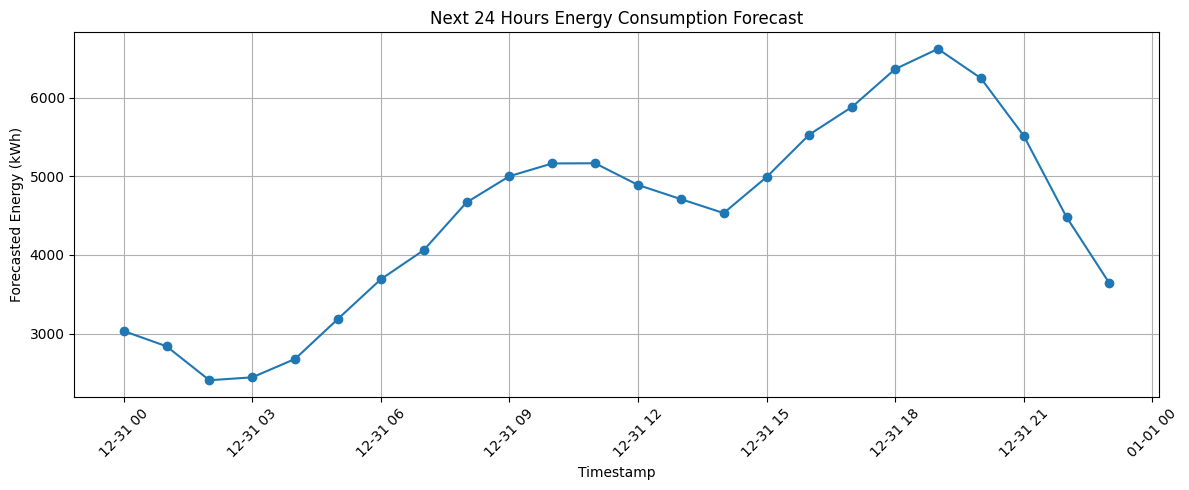

In [308]:
 #Future 24-Hour Forecast

plt.figure(figsize=(12, 5))

plt.plot(
    future_forecast_df['timestamp'],
    future_forecast_df['forecasted_energy_kwh'],
    marker='o'
)

plt.title('Next 24 Hours Energy Consumption Forecast')
plt.xlabel('Timestamp')
plt.ylabel('Forecasted Energy (kWh)')

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

In [309]:
#Save Final Forecast

future_forecast_df.to_csv(
    'final_energy_consumption_forecast.csv',
    index=False
)

print("Final forecast saved successfully!")

Final forecast saved successfully!


In [310]:
#Save Model Evaluation Results

model_results.to_csv(
    'model_comparison_results.csv',
    index=False
)

print("Model comparison results saved successfully!")

Model comparison results saved successfully!
